# 讲透一个强大算法模型，多项式回归 ！！

https://mp.weixin.qq.com/s/AxxBVUAncZlLM3b5b8lfGA

首先，在数学建模中，「回归」是指通过一些已知的数据，找出一个合适的函数（公式），让它尽可能贴近这些数据点。我们希望这个函数可以用来预测未来的数据。

举个简单的例子，你观察一个人每天走的步数和他的体重变化之间的关系，你收集了一些数据（步数，体重变化），你就想找一个公式能描述它们之间的规律。

### 什么是多项式回归？

如果你要找的这个函数是一个多项式函数（比如包含 、 这些项），这就叫多项式回归。

举例说明：

你有一堆点，比如：

x（步数）   y（体重变化）
1           2.1
2           2.9
3           3.0
4           2.4
5           1.0
这些点如果画出来，发现不是一条直线，而是弯曲的。如果你用一条直线去拟合这些点（这就是**线性回归**），效果很差。但是如果你用一个**二次曲线**（比如y=a+bx+cx^2）去拟合，就很贴合。这种拟合方式就叫**多项式回归**。

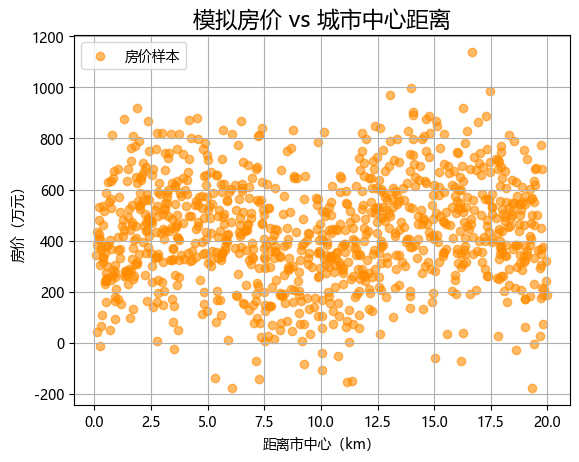

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, Lasso
import seaborn as sns

# 设置中文字体（如微软雅黑），确保中文正常显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 距离市中心的距离（km）
X = np.random.uniform(0, 20, 1000)
X = np.sort(X)

# 真实房价规律：模拟一种非线性规律 + 一点噪声
# 假设房价在市中心高，离开后下降，再有些地段略回升
y_true = (
    -0.8 * X**2 + 
    20 * X + 
    300 + 
    100 * np.sin(X / 2) + 
    np.random.normal(0, 200, size=X.shape)
)

# Reshape X 为列向量
X = X.reshape(-1, 1)

plt.scatter(X, y_true, color='darkorange', alpha=0.6, label='房价样本')
plt.title("模拟房价 vs 城市中心距离", fontsize=16)
plt.xlabel("距离市中心（km）")
plt.ylabel("房价（万元）")
plt.legend()
plt.grid(True)
plt.show()

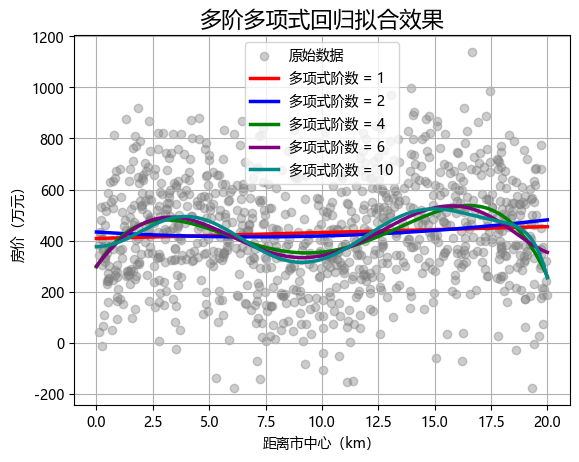

In [2]:
def plot_polynomial_models(degrees, X, y_true):
    X_plot = np.linspace(0, 20, 500).reshape(-1, 1)

    plt.scatter(X, y_true, color='gray', alpha=0.4, label='原始数据')

    colors = ['red', 'blue', 'green', 'purple', 'darkcyan', 'magenta']

    for i, degree in enumerate(degrees):
        model = make_pipeline(
            PolynomialFeatures(degree),
            LinearRegression()
        )
        model.fit(X, y_true)
        y_pred = model.predict(X_plot)
        plt.plot(X_plot, y_pred, color=colors[i % len(colors)], linewidth=2.5,
                 label=f"多项式阶数 = {degree}")

    plt.title("多阶多项式回归拟合效果", fontsize=16)
    plt.xlabel("距离市中心（km）")
    plt.ylabel("房价（万元）")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_polynomial_models([1, 2, 4, 6, 10], X, y_true)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.3, random_state=42)

def evaluate_model(degree):
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, r2

for d in range(1, 11):
    mse, r2 = evaluate_model(d)
    print(f"多项式阶数 {d:2d} -> MSE: {mse:.2f}, R²: {r2:.3f}")

多项式阶数  1 -> MSE: 39757.96, R²: 0.001
多项式阶数  2 -> MSE: 39573.07, R²: 0.006
多项式阶数  3 -> MSE: 39637.23, R²: 0.004
多项式阶数  4 -> MSE: 37233.89, R²: 0.065
多项式阶数  5 -> MSE: 36996.78, R²: 0.071
多项式阶数  6 -> MSE: 36714.95, R²: 0.078
多项式阶数  7 -> MSE: 36669.61, R²: 0.079
多项式阶数  8 -> MSE: 36391.70, R²: 0.086
多项式阶数  9 -> MSE: 36680.67, R²: 0.079
多项式阶数 10 -> MSE: 36654.94, R²: 0.079


In [ ]:
degrees = range(1, 15)
cv_errors = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    mse = -np.mean(cross_val_score(model, X, y_true, cv=5, scoring='neg_mean_squared_error'))
    cv_errors.append(mse)

plt.plot(degrees, cv_errors, marker='o', color='crimson')
plt.title("交叉验证：多项式阶数 vs 均方误差", fontsize=16)
plt.xlabel("多项式阶数")
plt.ylabel("平均MSE（交叉验证）")
plt.grid(True)
plt.show()

In [ ]:
degree = 10
alpha = 10# 正则化强度

# 构造输入特征
poly = PolynomialFeatures(degree)
X_poly = poly.fit_transform(X)

# Ridge 回归
ridge = Ridge(alpha=alpha)
ridge.fit(X_poly, y_true)
y_ridge = ridge.predict(X_poly)

# Lasso 回归
lasso = Lasso(alpha=alpha, max_iter=10000)
lasso.fit(X_poly, y_true)
y_lasso = lasso.predict(X_poly)

# 普通线性回归
linear = LinearRegression()
linear.fit(X_poly, y_true)
y_linear = linear.predict(X_poly)

# 可视化对比
plt.scatter(X, y_true, color='lightgray', label='数据')

plt.plot(X, y_linear, color='green', label='普通多项式回归', linewidth=2)
plt.plot(X, y_ridge, color='blue', label='Ridge（L2）', linewidth=2)
plt.plot(X, y_lasso, color='red', label='Lasso（L1）', linewidth=2)

plt.title("10阶多项式回归：正则化效果", fontsize=16)
plt.xlabel("距离市中心（km）")
plt.ylabel("房价（万元）")
plt.legend()
plt.grid(True)
plt.show()